In [11]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches


import astra

In [12]:
# ---------------------------------------------
# Load vectors with projection geometry
# ---------------------------------------------

vectors = np.load('projection_geometry.npy')
vectors = vectors[:,2:]*10 # in mm
print(f"{vectors[0,:]}")


# ---------------------------------------------
# Load projections and calculate att
# ---------------------------------------------

projection_images = np.load('projection_images.npy')
projection_images = projection_images.transpose(1,2,0,3) # (det_rows, n_proj, det_cols, 3)

eps = 0.5
transmission = np.log(np.maximum(projection_images[:,:,:,2], eps)/np.maximum(projection_images[:,:,:,0], eps))
transmission = np.clip(transmission, 0, None)  

det_rows, n_views, det_cols = transmission.shape
print(f"Detector rows: {det_rows}")
print(f"Detector cols: {det_cols}")
print(f"Number of projections: {n_views}")


# ---------------------------------------------
# Create astra objects
# ---------------------------------------------

# projection geometry
proj_geom = astra.create_proj_geom('cone_vec', det_rows, det_cols, vectors)

# Volume geometry
nx, ny, nz = 512, 512, 644
min_x, max_x = -390, 390
min_y, max_y = -390, 390
min_z, max_z = -531.3, 531.3

vol_geom = astra.create_vol_geom(nx, ny, nz,   
                                 min_x,
                                 max_x,
                                 min_y,
                                 max_y,
                                 min_z,
                                 max_z)

# Reconstruction mask
recon_mask = np.zeros((vol_geom['GridSliceCount'], vol_geom['GridRowCount'], vol_geom['GridColCount']))
recon_mask[:, 80:-80, 80:-80] = 1
recon_maskid = astra.data3d.create('-vol', vol_geom, data=recon_mask)


[   0.   650.  -531.3    0.  -450.  -531.3    1.     0.    -0.     0.
    0.     1. ]
Detector rows: 10
Detector cols: 1100
Number of projections: 40040


## **STRAIGHT SIRT IMPLEMENTATION**

In [5]:
# ---------------------------------------------
# Create ASTRA data objects
# ---------------------------------------------
proj_id = astra.data3d.create('-proj3d', proj_geom, transmission)
rec_id  = astra.data3d.create('-vol', vol_geom)

# ---------------------------------------------
# Reconstruction
# ---------------------------------------------
cfg = astra.astra_dict('SIRT3D_CUDA')
cfg['ProjectionDataId'] = proj_id
cfg['ReconstructionDataId'] = rec_id
cfg['option'] = {
    'MinConstraint': 0,
    'MaxConstraint': 0.25,
    'ReconstructionMaskId': recon_maskid,
}
alg_id = astra.algorithm.create(cfg)
astra.algorithm.run(alg_id, 500)

rec = astra.data3d.get(rec_id)

# ---------------------------------------------
# Cleanup
# ---------------------------------------------
astra.algorithm.delete(alg_id)
astra.data3d.delete([proj_id, rec_id])

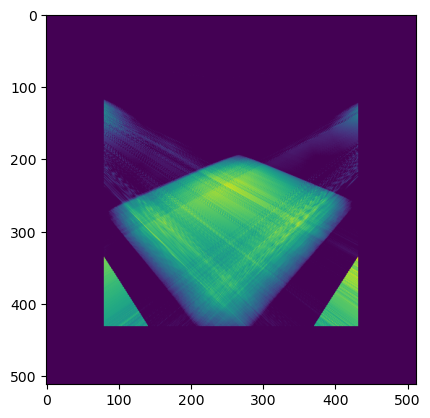

In [4]:
plt.imshow(rec[430])

## **SIRT LOOP IMPLEMENTATION**

In [6]:
def sirt_astra(
    proj,    
    proj_geom,
    vol_geom,
    recon_mask,
    n_iter=50,
    alpha = 1.0,
    eps = 1e-6,
    min_constraint = 0.0,
):

    vol_shape = (
    vol_geom["GridSliceCount"],
    vol_geom["GridRowCount"],
    vol_geom["GridColCount"]
    )

    proj_shape = proj.shape
    
    # ------------------------------------------------------------
    # Create ASTRA data objects
    # ------------------------------------------------------------
    x = np.zeros(vol_shape, dtype=np.float32)

    x_id = astra.data3d.create("-vol", vol_geom, x)
    fp_id = astra.data3d.create("-proj3d", proj_geom, 0.0)
    resid_id = astra.data3d.create("-proj3d", proj_geom, 0.0)
    bp_id = astra.data3d.create("-vol", vol_geom, 0.0)

    # These are used only for normalization.
    ones_vol = np.ones(vol_shape, dtype=np.float32)
    ones_proj = np.ones(proj_shape, dtype=np.float32)


    # ------------------------------------------------------------
    # Create reusable FP and BP algorithms
    # ------------------------------------------------------------
    cfg_fp = astra.astra_dict("FP3D_CUDA")
    cfg_fp["VolumeDataId"] = x_id
    cfg_fp["ProjectionDataId"] = fp_id
    fp_alg_id = astra.algorithm.create(cfg_fp)

    cfg_bp = astra.astra_dict("BP3D_CUDA")
    cfg_bp["ProjectionDataId"] = resid_id
    cfg_bp["ReconstructionDataId"] = bp_id
    bp_alg_id = astra.algorithm.create(cfg_bp)

    # --------------------------------------------------------
    # Precompute row normalization: row_sum = A 1
    # --------------------------------------------------------
    astra.data3d.store(x_id, ones_vol)
    astra.data3d.store(fp_id, np.zeros(proj_shape, dtype=np.float32)) # necessary because FP3D_CUDA adds the computed forward projection to the existing projection data object. If you do not clear it, the forward projection accumulates from previous iterations.

    astra.algorithm.run(fp_alg_id)
    row_sum = astra.data3d.get(fp_id).astype(np.float32)

    valid_row = row_sum > eps


    # --------------------------------------------------------
    # Precompute column normalization: col_sum = A.T 1
    # --------------------------------------------------------
    astra.data3d.store(resid_id, ones_proj)

    astra.algorithm.run(bp_alg_id)
    col_sum = astra.data3d.get(bp_id).astype(np.float32)

    valid_col = col_sum > eps

    # --------------------------------------------------------
    # Main SIRT loop
    # --------------------------------------------------------
    
    for it in range(n_iter):
        # Put current x into ASTRA.
        astra.data3d.store(x_id, x)

        # FP3D_CUDA adds into fp_id, so reset fp_id first.
        astra.data3d.store(fp_id, np.zeros(proj_shape, dtype=np.float32))

        # fp = A x
        astra.algorithm.run(fp_alg_id)
        fp = astra.data3d.get(fp_id).astype(np.float32)

        # residual = b - A x
        residual = proj - fp
        
        # row-normalized residual: R (b - A x)
        residual_norm = np.zeros_like(residual, dtype=np.float32)
        residual_norm[valid_row] = residual[valid_row] / row_sum[valid_row]

        # Backproject normalized residual.
        astra.data3d.store(resid_id, residual_norm)

        astra.algorithm.run(bp_alg_id)
        correction = astra.data3d.get(bp_id).astype(np.float32)

        # column-normalized correction: C A.T R residual
        update = np.zeros_like(x, dtype=np.float32)
        update[valid_col] = correction[valid_col] / col_sum[valid_col]

        if recon_mask is not None:
            update *= recon_mask

        # SIRT update
        x += alpha * update

        if min_constraint is not None:
            x = np.maximum(x, min_constraint).astype(np.float32)

        if recon_mask is not None:
            x *= recon_mask

        print(f"Iteration {it + 1}/{n_iter} done")
    
    return x 

In [7]:
x = sirt_astra(
    transmission,    
    proj_geom,
    vol_geom,
    recon_mask,
    n_iter=30,
    alpha = 1.0,
    eps = 1e-6,
    min_constraint = 0.0,
)

Iteration 1/30 done
Iteration 2/30 done
Iteration 3/30 done
Iteration 4/30 done
Iteration 5/30 done
Iteration 6/30 done
Iteration 7/30 done
Iteration 8/30 done
Iteration 9/30 done
Iteration 10/30 done
Iteration 11/30 done
Iteration 12/30 done
Iteration 13/30 done
Iteration 14/30 done
Iteration 15/30 done
Iteration 16/30 done
Iteration 17/30 done
Iteration 18/30 done
Iteration 19/30 done
Iteration 20/30 done
Iteration 21/30 done
Iteration 22/30 done
Iteration 23/30 done
Iteration 24/30 done
Iteration 25/30 done
Iteration 26/30 done
Iteration 27/30 done
Iteration 28/30 done
Iteration 29/30 done
Iteration 30/30 done


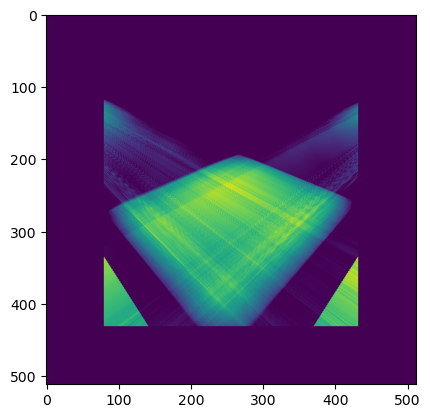

In [5]:
plt.imshow(x[430])

## **SUBSET-SIRT IMPLEMENTATION**

In [13]:
def Subset_SIRT(transmission, vectors, vol_geom, recon_maskid = None, n_subsets = 2, n_epochs = 30):
   
    # Get detector geometries
    det_rows, n_projections, det_cols = transmission.shape
    
    # Make randomized subsets of projection indices
    projection_indices = np.arange(n_projections)
    
    rng = np.random.default_rng(seed=12345)
    rng.shuffle(projection_indices)

    subsets = np.array_split(projection_indices, n_subsets)

    # Persistent reconstruction object
    rec_id  = astra.data3d.create('-vol', vol_geom)

    for epoch in range(n_epochs):

        #reshuffle subset order every epoch
        rng.shuffle(projection_indices)
        subsets = np.array_split(projection_indices, n_subsets)

        for subset in subsets:
        
            vectors_subset = vectors[subset,:]
            transmission_subset = transmission[:,subset,:]

            # ---------------------------------------------
            # Create ASTRA data objects
            # ---------------------------------------------
            proj_geom = astra.create_proj_geom('cone_vec', det_rows, det_cols, vectors_subset)
            proj_id = astra.data3d.create('-proj3d', proj_geom, transmission_subset)

            # ---------------------------------------------
            # Reconstruction
            # ---------------------------------------------
            cfg = astra.astra_dict('SIRT3D_CUDA')
            cfg['ProjectionDataId'] = proj_id
            cfg['ReconstructionDataId'] = rec_id
            cfg['option'] = {
                'MinConstraint': 0,
                'MaxConstraint': 0.25}
            
            if recon_maskid is not None:
                cfg["option"]["ReconstructionMaskId"] = recon_maskid

            alg_id = astra.algorithm.create(cfg)
            astra.algorithm.run(alg_id, 1)

            # ------------------------------------------------
            # Clean up subset-specific objects immediately
            # ------------------------------------------------
            astra.algorithm.delete(alg_id)
            astra.data3d.delete(proj_id)

        print(f"epoch {epoch + 1}/{n_epochs}")

    rec = astra.data3d.get(rec_id)
    astra.data3d.delete(rec_id)

    return rec

In [17]:
rec = Subset_SIRT(transmission, vectors, vol_geom, recon_maskid=recon_maskid, n_subsets = 3, n_epochs = 2)

epoch 1/2
epoch 2/2


In [19]:
500/60

8.333333333333334

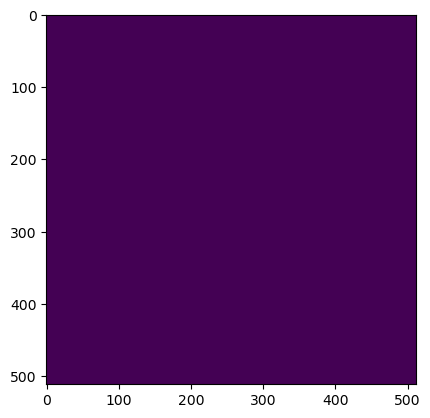

In [18]:
plt.imshow(rec[430])

In [1]:
def Subset_SIRT_cached(
    transmission,
    vectors,
    vol_geom,
    recon_maskid=None,
    n_subsets=2,
    n_epochs=30,
    iterations_per_subset=1,
    min_constraint=0.0,
    max_constraint=0.25,
    seed=12345,
):
    transmission = np.asarray(transmission, dtype=np.float32)
    vectors = np.asarray(vectors, dtype=np.float32)

    det_rows, n_views, det_cols = transmission.shape

    assert vectors.shape == (n_views, 12)

    rng = np.random.default_rng(seed)

    # Fixed subset membership.
    indices = rng.permutation(n_views)
    subsets = np.array_split(indices, n_subsets)

    rec_id = astra.data3d.create("-vol", vol_geom, 0.0)

    proj_ids = []
    alg_ids = []

    try:
        # Create each subset data object and SIRT algorithm once.
        for subset in subsets:
            vectors_s = vectors[subset, :].astype(np.float32)
            transmission_s = transmission[:, subset, :].astype(np.float32)

            proj_geom_s = astra.create_proj_geom(
                "cone_vec",
                det_rows,
                det_cols,
                vectors_s,
            )

            proj_id_s = astra.data3d.create(
                "-proj3d",
                proj_geom_s,
                transmission_s,
            )

            cfg = astra.astra_dict("SIRT3D_CUDA")
            cfg["ProjectionDataId"] = proj_id_s
            cfg["ReconstructionDataId"] = rec_id
            cfg["option"] = {
                "MinConstraint": float(min_constraint),
                "MaxConstraint": float(max_constraint),
            }

            if recon_maskid is not None:
                cfg["option"]["ReconstructionMaskId"] = recon_maskid

            alg_id_s = astra.algorithm.create(cfg)

            proj_ids.append(proj_id_s)
            alg_ids.append(alg_id_s)

        subset_order = np.arange(n_subsets)

        for epoch in range(n_epochs):
            rng.shuffle(subset_order)

            for isub in subset_order:
                astra.algorithm.run(
                    alg_ids[isub],
                    iterations_per_subset,
                )

            print(f"epoch {epoch + 1}/{n_epochs}")

        rec = astra.data3d.get(rec_id)

    finally:
        for alg_id in alg_ids:
            astra.algorithm.delete(alg_id)

        for proj_id in proj_ids:
            astra.data3d.delete(proj_id)

        astra.data3d.delete(rec_id)

    return rec

In [2]:
rec = Subset_SIRT_cached(transmission, vectors, vol_geom, recon_maskid=recon_maskid, n_subsets = 3, n_epochs = 2)

NameError: name 'transmission' is not defined